---
embed-resources: True
format:
    html:
        page-layout: full
        fontsize: 16px
title: 'Contexto de negocio'
author: 'Lorenzo Marquesini'
toc: False
---

# Bonsai Corp — ¿por qué importa consolidar el catálogo?

**Bonsai Corp** distribuye brócoli congelado desde **5 plantas** hacia **5 regiones**.  
Cada producto viaja en un envase primario → caja secundaria → pallet (1200 × 800 × 1800 mm).  
Hoy el catálogo de cajas está **fragmentado**: casi un tipo de caja por producto. Eso encarece packaging, flete e inventario, y se agrava con cada lanzamiento.

> **Misión:** reducir tipos de caja sin romper integridad del producto ni eficiencia de pallet,  
> minimizando **C_total = C_packaging + C_flete**, y dejando un protocolo reutilizable para futuros SKUs.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec

# Compatible con ejecución desde notebooks/ o desde la raíz del repo
_candidates = [Path.cwd(), Path.cwd().parent, Path("..").resolve()]
ROOT = next(p for p in _candidates if (p / "data" / "raw" / "catalogo_productos.csv").exists())
DATA = ROOT / "data" / "raw"

catalogo = pd.read_csv(DATA / "catalogo_productos.csv")
cajas = pd.read_csv(DATA / "especificaciones_cajas.csv")
ops = pd.read_csv(DATA / "operaciones_planta.csv")

# ── métricas de negocio ──────────────────────────────────────────
n_skus = catalogo["codigo_producto"].nunique()
n_tipos = catalogo["caja_tipo_id"].nunique()
skus_por_tipo = catalogo.groupby("caja_tipo_id").size()
pct_mono = (skus_por_tipo == 1).mean()
n_mono = int((skus_por_tipo == 1).sum())

c_pack = ops["costo_total"].sum()
c_flete = ops["costo_pallets_total"].sum()
c_total = c_pack + c_flete

vol_tipo = (
    catalogo.merge(ops[["codigo_producto", "volumen_producto_total"]], on="codigo_producto")
    .groupby("caja_tipo_id")["volumen_producto_total"]
    .sum()
)

def _tier(v: float) -> str:
    if v < 20_000:
        return "<20k\n(+10%)"
    if v < 50_000:
        return "20–50k\n(0%)"
    if v < 100_000:
        return "50–100k\n(−10%)"
    if v < 500_000:
        return "100–500k\n(−20%)"
    return "≥500k\n(−30%)"

tier_order = ["<20k\n(+10%)", "20–50k\n(0%)", "50–100k\n(−10%)", "100–500k\n(−20%)", "≥500k\n(−30%)"]
tier_counts = vol_tipo.map(_tier).value_counts().reindex(tier_order).fillna(0).astype(int)

util_media = cajas["utilizacion"].mean()

print(f"SKUs={n_skus:,} | tipos={n_tipos:,} | mono-SKU={n_mono} ({pct_mono:.0%})")
print(f"Costo total USD {c_total:,.0f}  (pack {c_pack/c_total:.0%} | flete {c_flete/c_total:.0%})")
print(f"Utilización media pallet: {util_media:.0%}")

SKUs=427 | tipos=204 | mono-SKU=117 (57%)
Costo total USD 209,235,094  (pack 14% | flete 86%)
Utilización media pallet: 84%


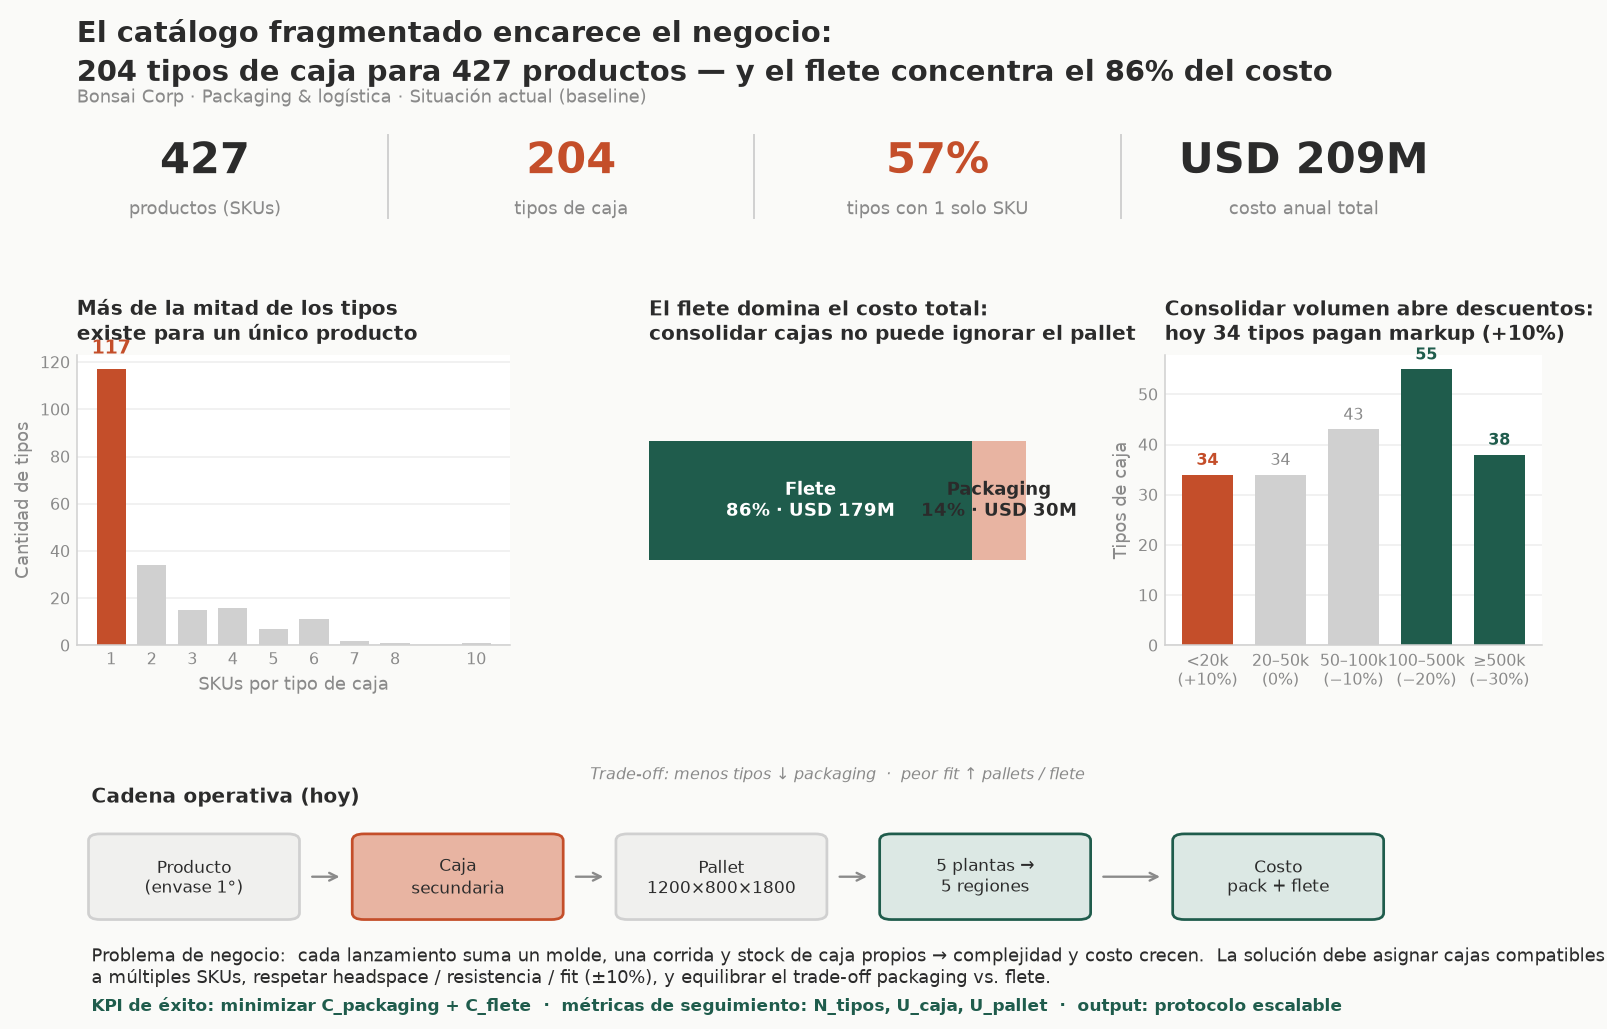

Guardado: /home/lorenn/Desktop/Universidad/Competencia-AlixPartners/outputs/figures/150_contexto_negocio_carilla.png


In [2]:
# ── Storytelling with Data: una sola carilla ─────────────────────
# Principios aplicados:
#   1. Un mensaje central (título = takeaway)
#   2. Menos tinta, más señal (gris secundario + 1 acento)
#   3. Etiquetas directas (sin leyendas innecesarias)
#   4. Pre-atención sobre el hallazgo clave (fragmentación)
#   5. Jerarquía visual: problema → costo → palanca → misión

INK = "#2B2B2B"
MUTED = "#8A8A8A"
LIGHT = "#D0D0D0"
ACCENT = "#C44E2A"       # énfasis del problema
ACCENT_SOFT = "#E8B4A2"
ACTION = "#1F5C4C"       # dirección / solución
BG = "#FAFAF8"
PANEL = "#FFFFFF"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.edgecolor": LIGHT,
    "axes.labelcolor": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "text.color": INK,
    "figure.facecolor": BG,
    "axes.facecolor": PANEL,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig = plt.figure(figsize=(11.5, 8.2), dpi=140)
gs = GridSpec(
    3, 3,
    figure=fig,
    height_ratios=[0.55, 1.35, 1.15],
    width_ratios=[1.15, 1.0, 1.0],
    hspace=0.55,
    wspace=0.35,
    left=0.06, right=0.97, top=0.86, bottom=0.08,
)

# ── Título takeaway (SWD: action title) ──────────────────────────
fig.text(
    0.06, 0.95,
    "El catálogo fragmentado encarece el negocio:\n"
    f"{n_tipos} tipos de caja para {n_skus} productos — y el flete concentra el {c_flete/c_total:.0%} del costo",
    fontsize=15, fontweight="bold", color=INK, va="top", linespacing=1.35,
)
fig.text(
    0.06, 0.885,
    "Bonsai Corp · Packaging & logística · Situación actual (baseline)",
    fontsize=9.5, color=MUTED, va="top",
)

# ── KPIs de contexto ─────────────────────────────────────────────
ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.set_xlim(0, 4)
ax_kpi.set_ylim(0, 1)
ax_kpi.axis("off")

kpis = [
    (f"{n_skus}", "productos (SKUs)", INK),
    (f"{n_tipos}", "tipos de caja", ACCENT),
    (f"{pct_mono:.0%}", "tipos con 1 solo SKU", ACCENT),
    (f"USD {c_total/1e6:.0f}M", "costo anual total", INK),
]
for i, (val, label, color) in enumerate(kpis):
    x = 0.35 + i * 1.0
    ax_kpi.text(x, 0.62, val, ha="center", va="center",
                fontsize=22, fontweight="bold", color=color)
    ax_kpi.text(x, 0.22, label, ha="center", va="center",
                fontsize=9, color=MUTED)
    if i < len(kpis) - 1:
        ax_kpi.axvline(x + 0.5, ymin=0.15, ymax=0.85, color=LIGHT, lw=1)

# ── Panel 1: fragmentación (mensaje principal) ───────────────────
ax1 = fig.add_subplot(gs[1, 0])
counts = skus_por_tipo.value_counts().sort_index()
xs = counts.index.to_numpy()
ys = counts.to_numpy()
colors = [ACCENT if x == 1 else LIGHT for x in xs]
bars = ax1.bar(xs, ys, color=colors, width=0.72, edgecolor="none")

ax1.set_xlabel("SKUs por tipo de caja", fontsize=9, color=MUTED)
ax1.set_ylabel("Cantidad de tipos", fontsize=9, color=MUTED)
ax1.set_xticks(xs)
ax1.tick_params(length=0, labelsize=8)
ax1.spines["left"].set_color(LIGHT)
ax1.spines["bottom"].set_color(LIGHT)
ax1.yaxis.grid(True, color="#EEEEEE", lw=0.8)
ax1.set_axisbelow(True)

# etiquetas solo en la barra destacada + total implícito
ax1.text(
    1, n_mono + max(ys) * 0.04, f"{n_mono}",
    ha="center", va="bottom", fontsize=10, fontweight="bold", color=ACCENT,
)
ax1.set_title(
    "Más de la mitad de los tipos\nexiste para un único producto",
    fontsize=10.5, fontweight="bold", color=INK, loc="left", pad=8,
)

# ── Panel 2: estructura de costo ─────────────────────────────────
ax2 = fig.add_subplot(gs[1, 1])
parts = [c_flete, c_pack]
labels = ["Flete", "Packaging"]
part_colors = [ACTION, ACCENT_SOFT]
y0 = 0
for val, lab, col in zip(parts, labels, part_colors):
    ax2.barh([0], [val], left=y0, color=col, height=0.45, edgecolor="none")
    mid = y0 + val / 2
    ax2.text(
        mid, 0,
        f"{lab}\n{val/c_total:.0%} · USD {val/1e6:.0f}M",
        ha="center", va="center", fontsize=9, fontweight="bold",
        color="white" if lab == "Flete" else INK,
    )
    y0 += val

ax2.set_xlim(0, c_total)
ax2.set_ylim(-0.55, 0.55)
ax2.axis("off")
ax2.set_title(
    "El flete domina el costo total:\nconsolidar cajas no puede ignorar el pallet",
    fontsize=10.5, fontweight="bold", color=INK, loc="left", pad=8,
)

# nota de trade-off debajo del stacked bar
ax2.text(
    0.5, -0.42,
    "Trade-off: menos tipos ↓ packaging  ·  peor fit ↑ pallets / flete",
    transform=ax2.transAxes, ha="center", va="top",
    fontsize=8, color=MUTED, style="italic",
)

# ── Panel 3: descuentos por volumen (palanca) ────────────────────
ax3 = fig.add_subplot(gs[1, 2])
bar_colors = [ACCENT if i == 0 else (ACTION if i >= 3 else LIGHT) for i in range(len(tier_order))]
ax3.bar(range(len(tier_order)), tier_counts.values, color=bar_colors, width=0.7, edgecolor="none")
ax3.set_xticks(range(len(tier_order)))
ax3.set_xticklabels(tier_order, fontsize=7.5, color=MUTED)
ax3.tick_params(length=0, labelsize=8)
ax3.spines["left"].set_color(LIGHT)
ax3.spines["bottom"].set_color(LIGHT)
ax3.yaxis.grid(True, color="#EEEEEE", lw=0.8)
ax3.set_axisbelow(True)
ax3.set_ylabel("Tipos de caja", fontsize=9, color=MUTED)

for i, v in enumerate(tier_counts.values):
    ax3.text(i, v + 1.2, str(v), ha="center", va="bottom", fontsize=8,
             fontweight="bold" if i in (0, 3, 4) else "normal",
             color=ACCENT if i == 0 else (ACTION if i >= 3 else MUTED))

ax3.set_title(
    "Consolidar volumen abre descuentos:\nhoy 34 tipos pagan markup (+10%)",
    fontsize=10.5, fontweight="bold", color=INK, loc="left", pad=8,
)

# ── Panel inferior: cadena de valor + problema a resolver ────────
ax4 = fig.add_subplot(gs[2, :])
ax4.set_xlim(0, 10)
ax4.set_ylim(0, 3)
ax4.axis("off")

ax4.text(0.1, 2.55, "Cadena operativa (hoy)", fontsize=10.5,
         fontweight="bold", color=INK)

steps = [
    ("Producto\n(envase 1°)", 0.8),
    ("Caja\nsecundaria", 2.6),
    ("Pallet\n1200×800×1800", 4.4),
    ("5 plantas →\n5 regiones", 6.2),
    ("Costo\npack + flete", 8.2),
]
for i, (label, x) in enumerate(steps):
    face = ACCENT_SOFT if i == 1 else ("#DCE8E4" if i >= 3 else "#F0F0EE")
    edge = ACCENT if i == 1 else (ACTION if i >= 3 else LIGHT)
    box = mpatches.FancyBboxPatch(
        (x - 0.7, 1.15), 1.4, 1.0,
        boxstyle="round,pad=0.02,rounding_size=0.08",
        linewidth=1.4, edgecolor=edge, facecolor=face,
    )
    ax4.add_patch(box)
    ax4.text(x, 1.65, label, ha="center", va="center",
             fontsize=8.5, color=INK, linespacing=1.25)
    if i < len(steps) - 1:
        ax4.annotate(
            "", xy=(steps[i + 1][1] - 0.78, 1.65), xytext=(x + 0.78, 1.65),
            arrowprops=dict(arrowstyle="->", color=MUTED, lw=1.2),
        )

ax4.text(
    0.1, 0.55,
    "Problema de negocio:  "
    "cada lanzamiento suma un molde, una corrida y stock de caja propios → complejidad y costo crecen.  "
    "La solución debe asignar cajas compatibles a múltiples SKUs, "
    "respetar headspace / resistencia / fit (±10%), "
    "y equilibrar el trade-off packaging vs. flete.",
    fontsize=9, color=INK, va="center", wrap=True,
)
ax4.text(
    0.1, 0.08,
    "KPI de éxito: minimizar C_packaging + C_flete  ·  métricas de seguimiento: N_tipos, U_caja, U_pallet  ·  output: protocolo escalable",
    fontsize=8.5, color=ACTION, fontweight="bold", va="center",
)

out = ROOT / "outputs" / "figures" / "150_contexto_negocio_carilla.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Guardado: {out}")

### Lectura en una frase

Bonsai opera un portafolio de **427 SKUs** con **204 tipos de caja**; el **57%** de esos tipos sirve a un solo producto.  
El costo anual supera **USD 209 M**, y el **flete (~86%)** manda: consolidar sin cuidar el pallet puede salir caro.  
La palanca económica es **subir de tier de descuento** al concentrar volumen en menos tipos — sin violar restricciones de diseño ni resistencia.